In [9]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- 1. CONFIGURATION AND HYPERPARAMETERS ---
IMG_SIZE = 128
NUM_CLASSES = 3  # Pet, Boundary, Background (1, 2, 3 in original mask, adjusted to 0, 1, 2)
BATCH_SIZE = 64
EPOCHS = 10
BUFFER_SIZE = 1000

# --- 2. DATA LOADING AND PREPROCESSING UTILITIES ---

def normalize(input_image, input_mask):
    """Normalize image values and adjust mask labels."""
    # Scale image to 0-1 range
    input_image = tf.cast(input_image, tf.float32) / 255.0

    # Convert the mask to integer type (for sparse labels) and remove the
    # channel dimension (tf.squeeze) to match the expected sparse input shape
    # (BATCH, H, W) for SparseCategoricalCrossentropy and MeanIoU.
    input_mask = tf.cast(input_mask, tf.int32)
    # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2.
    input_mask -= 1
    # Remove the final channel dimension (which is 1)
    input_mask = tf.squeeze(input_mask, axis=-1)

    return input_image, input_mask

@tf.function
def load_image_train(datapoint):
    """Loads, resizes, and processes a training image and mask."""
    input_image = tf.image.resize(datapoint['image'], (IMG_SIZE, IMG_SIZE))
    input_mask = tf.image.resize(
        datapoint['segmentation_mask'], (IMG_SIZE, IMG_SIZE), method='nearest'
    )

    # Optional data augmentation (random horizontal flip)
    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        input_mask = tf.image.flip_left_right(input_mask)

    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask

def load_image_test(datapoint):
    """Loads, resizes, and processes a test image and mask (no augmentation)."""
    input_image = tf.image.resize(datapoint['image'], (IMG_SIZE, IMG_SIZE))
    input_mask = tf.image.resize(
        datapoint['segmentation_mask'], (IMG_SIZE, IMG_SIZE), method='nearest'
    )

    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask

# --- 3. PURE U-NET MODEL ARCHITECTURE ---

def double_conv_block(inputs, filters):
    """A standard block used in U-Net: two Conv2D layers followed by ReLU."""
    # First convolution layer
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    # Second convolution layer
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', kernel_initializer='he_normal')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

def build_unet_model(output_channels):
    """Builds a classic U-Net model from scratch (no pretrained encoder)."""

    inputs = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3])

    # --- ENCODER (Downsampling) ---

    # Block 1 (128x128)
    c1 = double_conv_block(inputs, 64)
    p1 = tf.keras.layers.MaxPool2D((2, 2))(c1) # 64x64

    # Block 2 (64x64)
    c2 = double_conv_block(p1, 128)
    p2 = tf.keras.layers.MaxPool2D((2, 2))(c2) # 32x32

    # Block 3 (32x32)
    c3 = double_conv_block(p2, 256)
    p3 = tf.keras.layers.MaxPool2D((2, 2))(c3) # 16x16

    # Block 4 (16x16)
    c4 = double_conv_block(p3, 512)
    p4 = tf.keras.layers.MaxPool2D((2, 2))(c4) # 8x8

    # --- BOTTLENECK (8x8) ---
    bottleneck = double_conv_block(p4, 1024)

    # --- DECODER (Upsampling) ---

    # Block 4 Up (16x16)
    u4 = tf.keras.layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(bottleneck)
    u4 = tf.keras.layers.concatenate([u4, c4]) # Skip connection
    c8 = double_conv_block(u4, 512)

    # Block 3 Up (32x32)
    u3 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c8)
    u3 = tf.keras.layers.concatenate([u3, c3]) # Skip connection
    c7 = double_conv_block(u3, 256)

    # Block 2 Up (64x64)
    u2 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u2 = tf.keras.layers.concatenate([u2, c2]) # Skip connection
    c6 = double_conv_block(u2, 128)

    # Block 1 Up (128x128)
    u1 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u1 = tf.keras.layers.concatenate([u1, c1]) # Skip connection
    c5 = double_conv_block(u1, 64)

    # --- OUTPUT LAYER (1x1 Convolution) ---
    # 1x1 conv to map features to the required number of classes, followed by softmax
    outputs = tf.keras.layers.Conv2D(output_channels, 1, activation='softmax')(c5)

    return tf.keras.Model(inputs=[inputs], outputs=[outputs])

# --- 4. VISUALIZATION UTILITIES ---

def create_mask(pred_mask):
    """Convert the model's output (logits) to a predicted mask."""
    # Argmax returns the index of the largest value along the last axis (channels)
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis] # Add channel dimension back
    return pred_mask[0] # Return the first item in the batch

def display(display_list, title_list=None):
    """Displays a list of images/masks side-by-side."""
    plt.figure(figsize=(15, 5))

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        if title_list:
            plt.title(title_list[i])

        # Display the image/mask
        img_to_display = tf.keras.utils.array_to_img(display_list[i])
        plt.imshow(img_to_display)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

def show_predictions(model, dataset=None, num=1):
    """Plots a set of input images, true masks, and predicted masks."""
    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = model.predict(image)

            for i in range(num):
                # The true mask 'mask' in the dataset is now (H, W), but display expects (H, W, 1) or (H, W, 3)
                # We need to add the channel back for display, but keep the integer type.
                mask_display = mask[i:i+1][..., tf.newaxis]

                display([image[i], mask_display[0], create_mask(pred_mask[i:i+1])],
                        title_list=['Input Image', 'True Mask', 'Predicted Mask'])
    else:
        # Example for initial prediction before training (shows random noise)
        pass




TensorFlow Version: 2.19.0

[STEP 1/5] Loading and preparing Oxford-IIIT Pets Dataset...

[STEP 2/5] Displaying sample data (Input Image & True Mask):


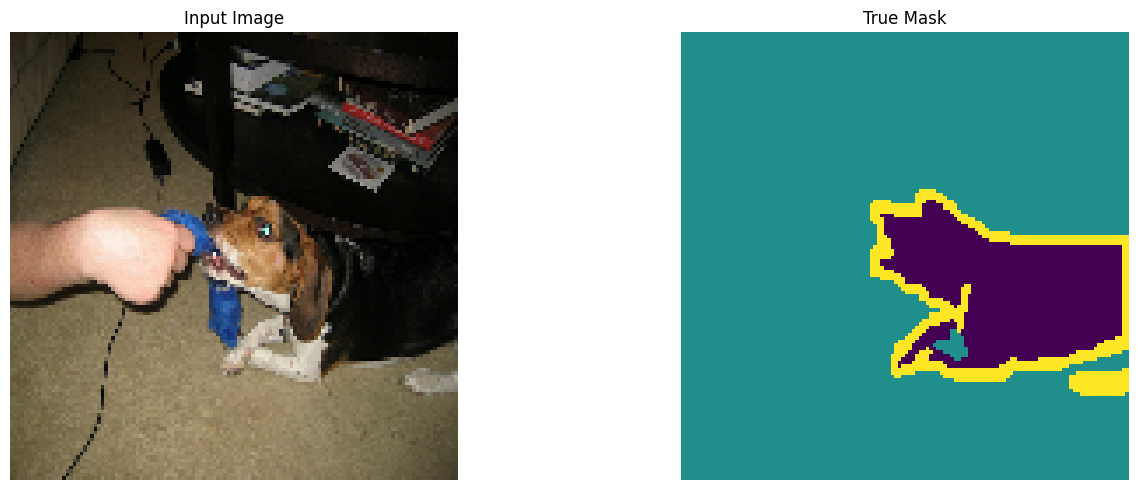

In [11]:
# --- 5. MAIN EXECUTION FUNCTION ---

print("TensorFlow Version:", tf.__version__)

# --- A. LOAD AND PREPARE DATA ---
print("\n[STEP 1/5] Loading and preparing Oxford-IIIT Pets Dataset...")
# Using '4.0.0' to resolve the earlier AssertionError.
dataset, info = tfds.load('oxford_iiit_pet:4.0.0', with_info=True)

# Split the dataset
train_ds = dataset['train'].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = dataset['test'].map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)

# Create batched and prefetch datasets
train_batches = (
    train_ds
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)
test_batches = test_ds.batch(BATCH_SIZE)

# --- B. DISPLAY INITIAL SAMPLES (Image and True Mask) ---
print("\n[STEP 2/5] Displaying sample data (Input Image & True Mask):")
for image, mask in train_batches.take(1):
    sample_image, sample_mask = image[0], mask[0]
    # The mask is now (H, W), so we add the channel back for display purposes
    sample_mask_display = sample_mask[..., tf.newaxis]
    display([sample_image, sample_mask_display], title_list=['Input Image', 'True Mask'])
    break # Only show one sample batch


In [13]:
# --- C. BUILD, COMPILE, AND TRAIN MODEL ---
print("\n[STEP 3/5] Building and compiling U-Net model...")
# Using the new scratch-built U-Net
unet_model = build_unet_model(NUM_CLASSES)

# Loss: SparseCategoricalCrossentropy is ideal for pixel-wise classification
# Metrics: MeanIoU is the standard evaluation metric for segmentation
unet_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=[tf.keras.metrics.MeanIoU(
        num_classes=NUM_CLASSES,
        name='mean_iou',
        sparse_y_true=True,
        sparse_y_pred=False
    ), 'accuracy']
)



TRAIN_STEPS = info.splits['train'].num_examples // BATCH_SIZE
VAL_STEPS = info.splits['test'].num_examples // BATCH_SIZE

print(f"Starting training for {EPOCHS} epochs (Train steps: {TRAIN_STEPS}, Val steps: {VAL_STEPS})")

history = unet_model.fit(
    train_batches,
    epochs=EPOCHS,
    steps_per_epoch=TRAIN_STEPS,
    validation_steps=VAL_STEPS,
    validation_data=test_batches,
    verbose=1
)



[STEP 3/5] Building and compiling U-Net model...
Starting training for 10 epochs (Train steps: 57, Val steps: 57)
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.6766 - loss: 0.7604 - mean_iou: 0.3823 - val_accuracy: 0.4359 - val_loss: 75.5724 - val_mean_iou: 0.1956
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7962 - loss: 0.5156 - mean_iou: 0.5435 - val_accuracy: 0.4973 - val_loss: 5.9873 - val_mean_iou: 0.2661
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8343 - loss: 0.4280 - mean_iou: 0.6073 - val_accuracy: 0.4971 - val_loss: 4.8467 - val_mean_iou: 0.2785
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8520 - loss: 0.3794 - mean_iou: 0.6368 - val_accuracy: 0.6608 - val_loss: 2.1893 - val_mean_iou: 0.4317
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.8649 - loss: 0.3492 - mean_iou: 0.6587 - val_accuracy: 0.8230 - val_loss: 0.6035 - val_mean_iou: 0.6159
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 65s 


[STEP 4/5] Evaluating model on test dataset...

Final Test Loss: 0.3400
Final Test Mean IoU (Intersection over Union): 0.6868
Final Test Accuracy: 0.8748

[STEP 5/5] Displaying post-training predictions (Input, True Mask, Predicted Mask):
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step


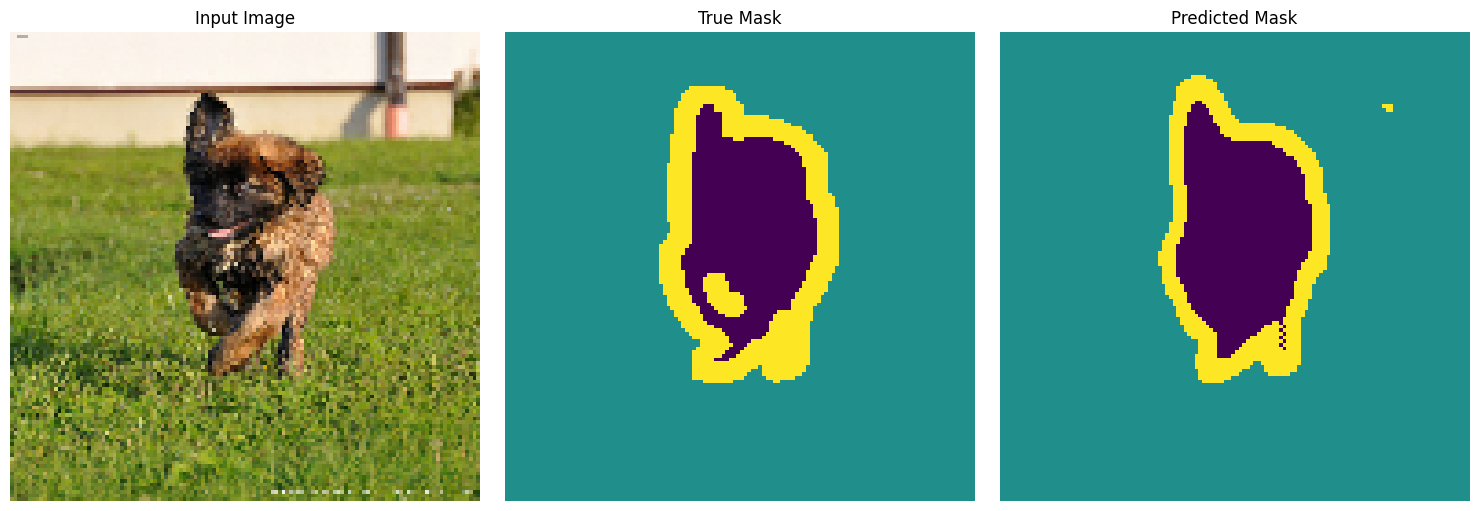

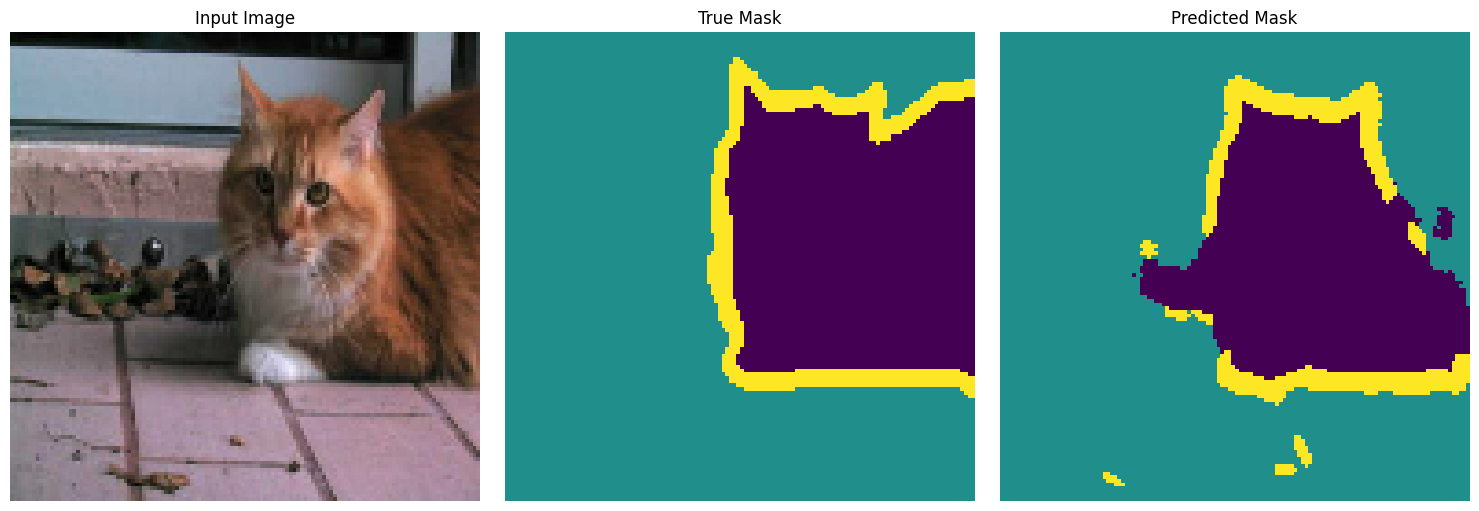

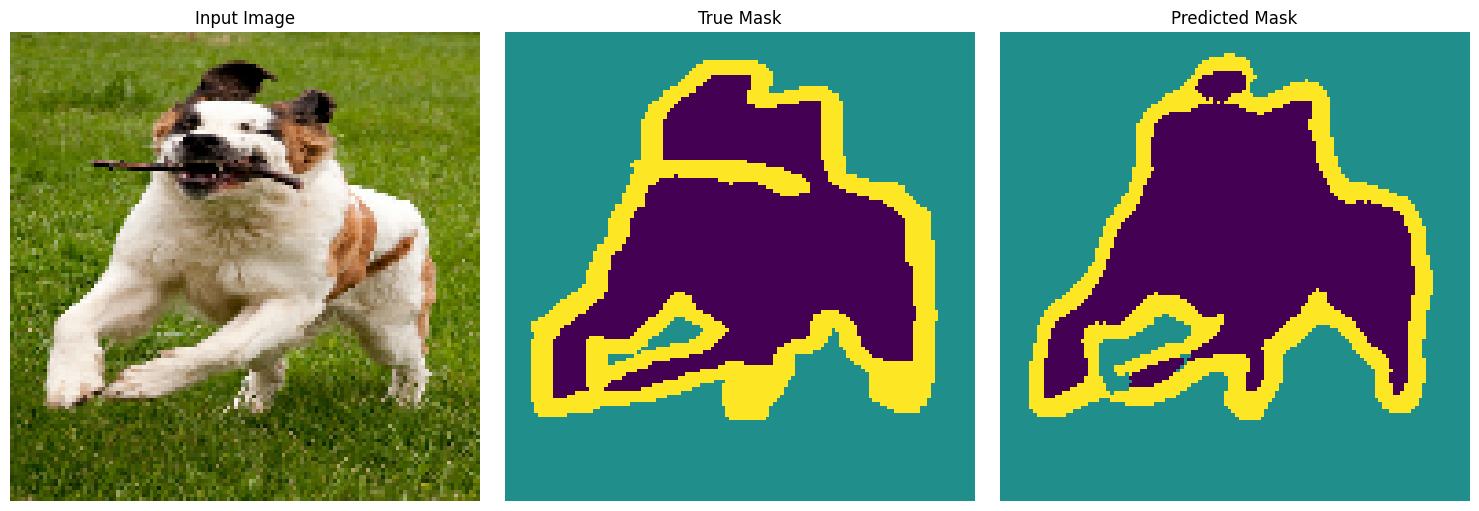

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


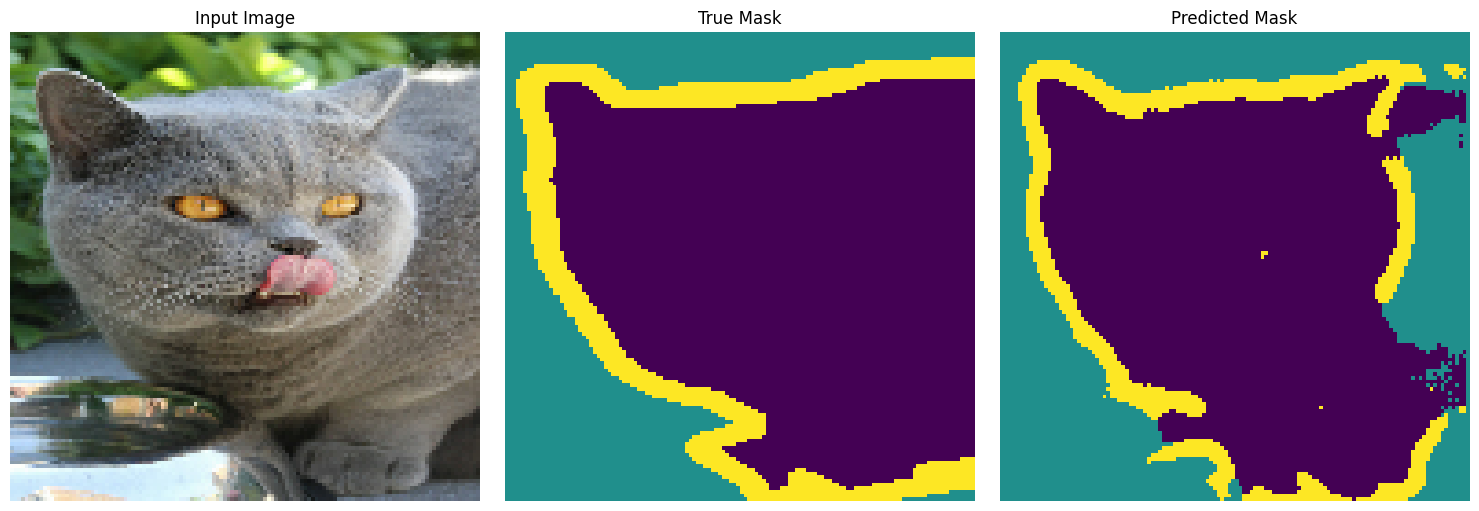

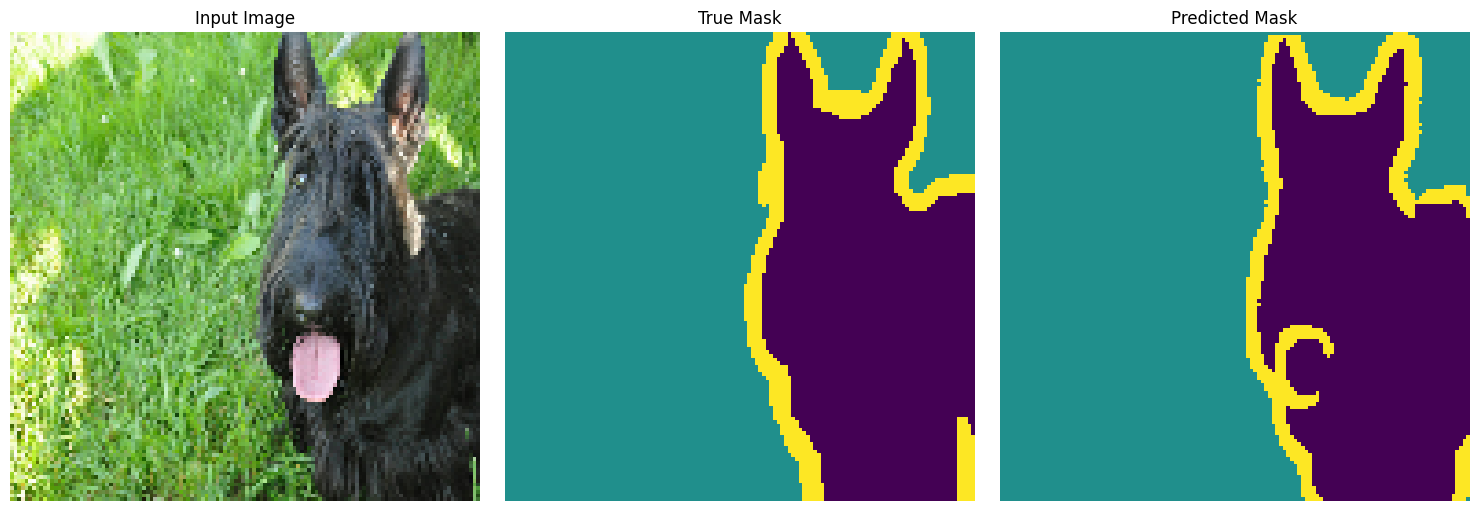

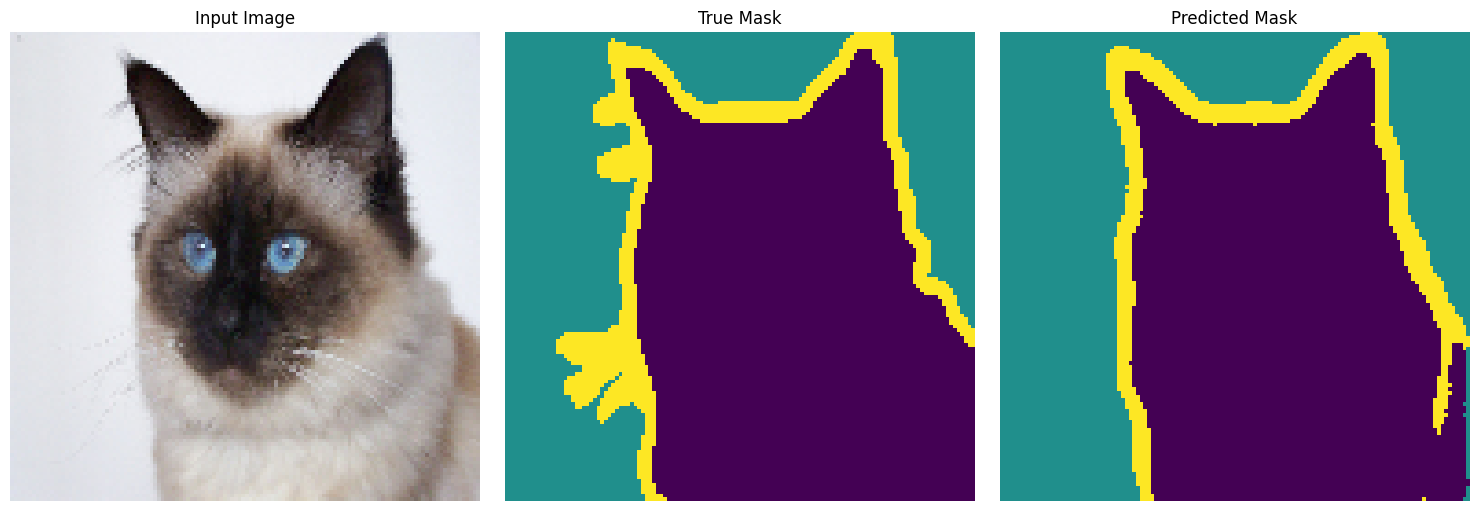

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


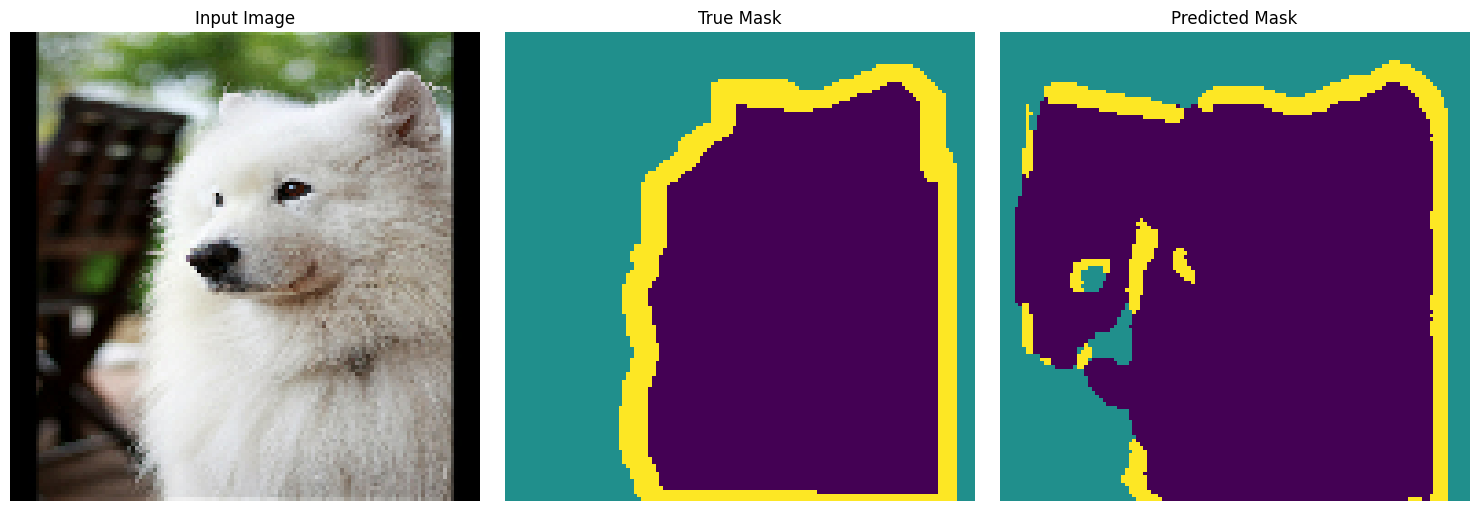

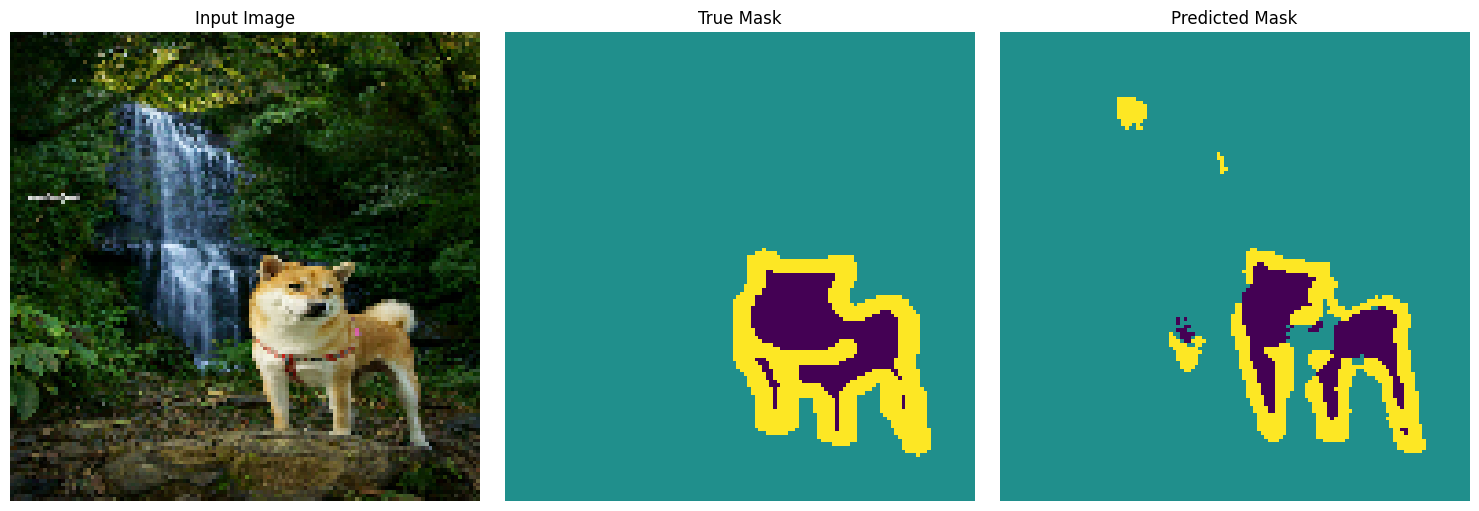

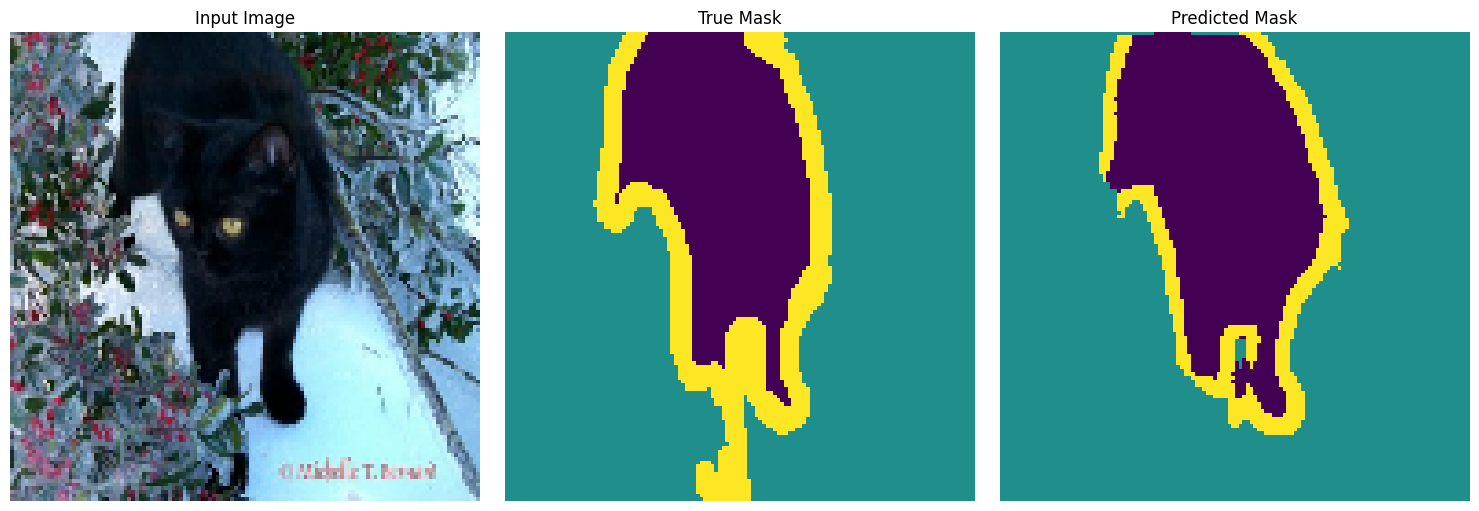

In [14]:
# --- D. EVALUATE MODEL ---
print("\n[STEP 4/5] Evaluating model on test dataset...")
loss, mean_iou, accuracy = unet_model.evaluate(test_batches, steps=VAL_STEPS, verbose=0)
print(f"\nFinal Test Loss: {loss:.4f}")
print(f"Final Test Mean IoU (Intersection over Union): {mean_iou:.4f}")
print(f"Final Test Accuracy: {accuracy:.4f}")

# --- E. DISPLAY FINAL PREDICTED SAMPLES ---
print("\n[STEP 5/5] Displaying post-training predictions (Input, True Mask, Predicted Mask):")
# Take a few samples from the validation set for visualization
show_predictions(unet_model, test_batches, num=3)